In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings

from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, f1_score,
                             precision_score, recall_score)
import lightgbm as lgb
import xgboost  as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

OUTPUT_DIR = '../../../output/alternative_model'

# ── Load pre-built splits ──────────────────────────────────────────────────────
X_train = pd.read_csv(f'{OUTPUT_DIR}/X_train.csv')
X_val   = pd.read_csv(f'{OUTPUT_DIR}/X_val.csv')
X_test  = pd.read_csv(f'{OUTPUT_DIR}/X_test.csv')
y_train = pd.read_csv(f'{OUTPUT_DIR}/y_train.csv').squeeze()
y_val   = pd.read_csv(f'{OUTPUT_DIR}/y_val.csv').squeeze()
y_test  = pd.read_csv(f'{OUTPUT_DIR}/y_test.csv').squeeze()

with open(f'{OUTPUT_DIR}/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

print('Splits loaded:')
print(f'  Train: {X_train.shape} | default rate: {y_train.mean()*100:.2f}%')
print(f'  Val  : {X_val.shape}   | default rate: {y_val.mean()*100:.2f}%')
print(f'  Test : {X_test.shape}  | default rate: {y_test.mean()*100:.2f}%')

d:\Project_A\Credit-Scoring\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Splits loaded:
  Train: (7000, 21) | default rate: 35.79%
  Val  : (1500, 21)   | default rate: 35.80%
  Test : (1500, 21)  | default rate: 35.73%


## Helper — Evaluation Suite

In [2]:
results_log = {}  # accumulates model comparison

def evaluate_model(name, model, X_eval, y_eval, proba=None, threshold=0.5):
    """Print full metrics and store in results_log."""
    if proba is None:
        proba = model.predict_proba(X_eval)[:, 1]
    pred  = (proba >= threshold).astype(int)

    auc  = roc_auc_score(y_eval, proba)
    f1   = f1_score(y_eval, pred)
    prec = precision_score(y_eval, pred)
    rec  = recall_score(y_eval, pred)

    results_log[name] = {'AUC': auc, 'F1': f1, 'Precision': prec, 'Recall': rec}

    print(f'\n── {name} ──────────────────────────────')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print()
    print(classification_report(y_eval, pred, target_names=['No Default', 'Default']))
    return proba


def plot_roc(names_probas, y_true, title='ROC Curves Comparison'):
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, proba in names_probas:
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc = roc_auc_score(y_true, proba)
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'], ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

print('Helper functions ready.')

Helper functions ready.


## Model 1 — LightGBM

In [3]:
# Class weight for imbalanced data
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class weight (neg/pos): {pos_weight:.2f}')

lgb_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'n_estimators'     : 1000,
    'learning_rate'    : 0.03,
    'num_leaves'       : 31,
    'max_depth'        : 6,
    'min_child_samples': 30,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'scale_pos_weight' : pos_weight,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f'Best iteration: {lgb_model.best_iteration_}')

Class weight (neg/pos): 1.79
Best iteration: 35



── LightGBM (Val) ──────────────────────────────
  ROC-AUC   : 0.7079
  F1 Score  : 0.5512
  Precision : 0.5371
  Recall    : 0.5661

              precision    recall  f1-score   support

  No Default       0.75      0.73      0.74       963
     Default       0.54      0.57      0.55       537

    accuracy                           0.67      1500
   macro avg       0.64      0.65      0.65      1500
weighted avg       0.67      0.67      0.67      1500


── LightGBM (Test) ──────────────────────────────
  ROC-AUC   : 0.7140
  F1 Score  : 0.5420
  Precision : 0.5304
  Recall    : 0.5541

              precision    recall  f1-score   support

  No Default       0.75      0.73      0.74       964
     Default       0.53      0.55      0.54       536

    accuracy                           0.67      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.67      0.67      0.67      1500



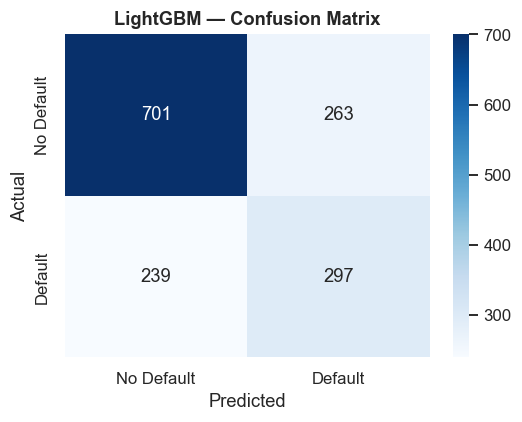

In [4]:
lgb_proba_val  = evaluate_model('LightGBM (Val)',  lgb_model, X_val,  y_val)
lgb_proba_test = evaluate_model('LightGBM (Test)', lgb_model, X_test, y_test)

plot_confusion(y_test, (lgb_proba_test >= 0.5).astype(int), 'LightGBM — Confusion Matrix')

## Model 2 — XGBoost

In [5]:
# early_stopping_rounds is a constructor param in XGBoost >= 2.0
xgb_params = {
    'objective'           : 'binary:logistic',
    'eval_metric'         : 'auc',
    'n_estimators'        : 1000,
    'learning_rate'       : 0.03,
    'max_depth'           : 4,
    'min_child_weight'    : 10,
    'subsample'           : 0.8,
    'colsample_bytree'    : 0.8,
    'gamma'               : 0.1,
    'reg_alpha'           : 0.5,
    'reg_lambda'          : 1.0,
    'scale_pos_weight'    : pos_weight,
    'random_state'        : 42,
    'n_jobs'              : -1,
    'tree_method'         : 'hist',
    'early_stopping_rounds': 50      # moved to constructor in XGBoost >= 2.0
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f'Best iteration: {xgb_model.best_iteration}')

[0]	validation_0-auc:0.69829
[100]	validation_0-auc:0.70979
[200]	validation_0-auc:0.70987
[224]	validation_0-auc:0.70934
Best iteration: 175



── XGBoost (Val) ──────────────────────────────
  ROC-AUC   : 0.7106
  F1 Score  : 0.5888
  Precision : 0.5161
  Recall    : 0.6853

              precision    recall  f1-score   support

  No Default       0.79      0.64      0.71       963
     Default       0.52      0.69      0.59       537

    accuracy                           0.66      1500
   macro avg       0.65      0.66      0.65      1500
weighted avg       0.69      0.66      0.66      1500


── XGBoost (Test) ──────────────────────────────
  ROC-AUC   : 0.7172
  F1 Score  : 0.5714
  Precision : 0.4952
  Recall    : 0.6754

              precision    recall  f1-score   support

  No Default       0.77      0.62      0.69       964
     Default       0.50      0.68      0.57       536

    accuracy                           0.64      1500
   macro avg       0.63      0.65      0.63      1500
weighted avg       0.67      0.64      0.65      1500



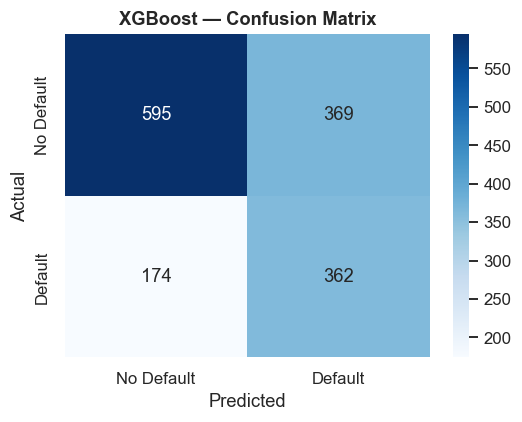

In [6]:
xgb_proba_val  = evaluate_model('XGBoost (Val)',  xgb_model, X_val,  y_val)
xgb_proba_test = evaluate_model('XGBoost (Test)', xgb_model, X_test, y_test)

plot_confusion(y_test, (xgb_proba_test >= 0.5).astype(int), 'XGBoost — Confusion Matrix')

## Model Comparison

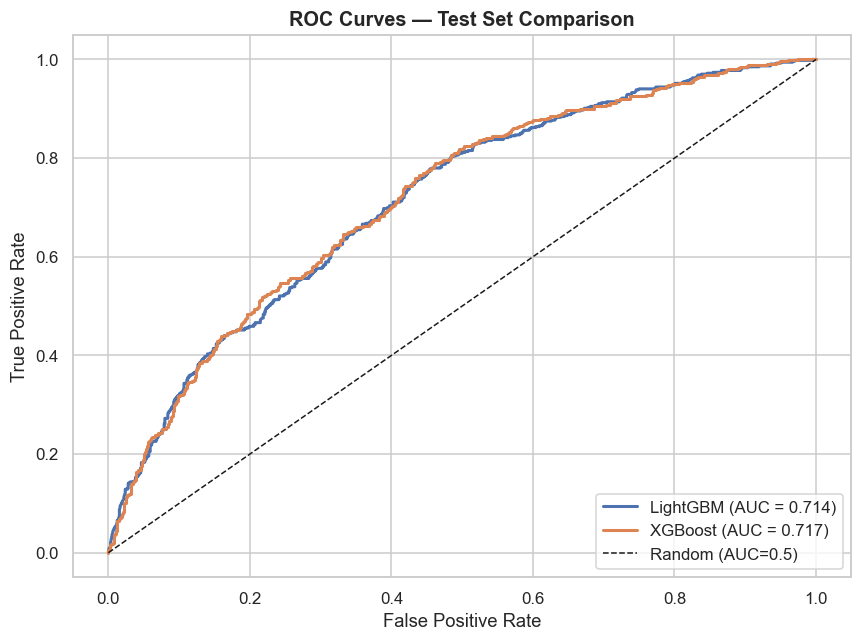

In [7]:
# ROC curve comparison on test set
plot_roc([
    ('LightGBM', lgb_proba_test),
    ('XGBoost',  xgb_proba_test),
], y_test, title='ROC Curves — Test Set Comparison')

In [8]:
# Summary table (test set)
test_results = {
    'LightGBM': {
        'AUC'      : roc_auc_score(y_test, lgb_proba_test),
        'F1'       : f1_score(y_test, (lgb_proba_test >= 0.5).astype(int)),
        'Precision': precision_score(y_test, (lgb_proba_test >= 0.5).astype(int)),
        'Recall'   : recall_score(y_test, (lgb_proba_test >= 0.5).astype(int)),
    },
    'XGBoost': {
        'AUC'      : roc_auc_score(y_test, xgb_proba_test),
        'F1'       : f1_score(y_test, (xgb_proba_test >= 0.5).astype(int)),
        'Precision': precision_score(y_test, (xgb_proba_test >= 0.5).astype(int)),
        'Recall'   : recall_score(y_test, (xgb_proba_test >= 0.5).astype(int)),
    },
}

results_df = pd.DataFrame(test_results).T.round(4)
results_df['Best'] = ''
best_model_name = results_df['AUC'].idxmax()
results_df.loc[best_model_name, 'Best'] = '⭐'
print('\n=== TEST SET RESULTS ===')
print(results_df.to_string())


=== TEST SET RESULTS ===
             AUC      F1  Precision  Recall Best
LightGBM  0.7140  0.5420     0.5304  0.5541     
XGBoost   0.7172  0.5714     0.4952  0.6754    ⭐


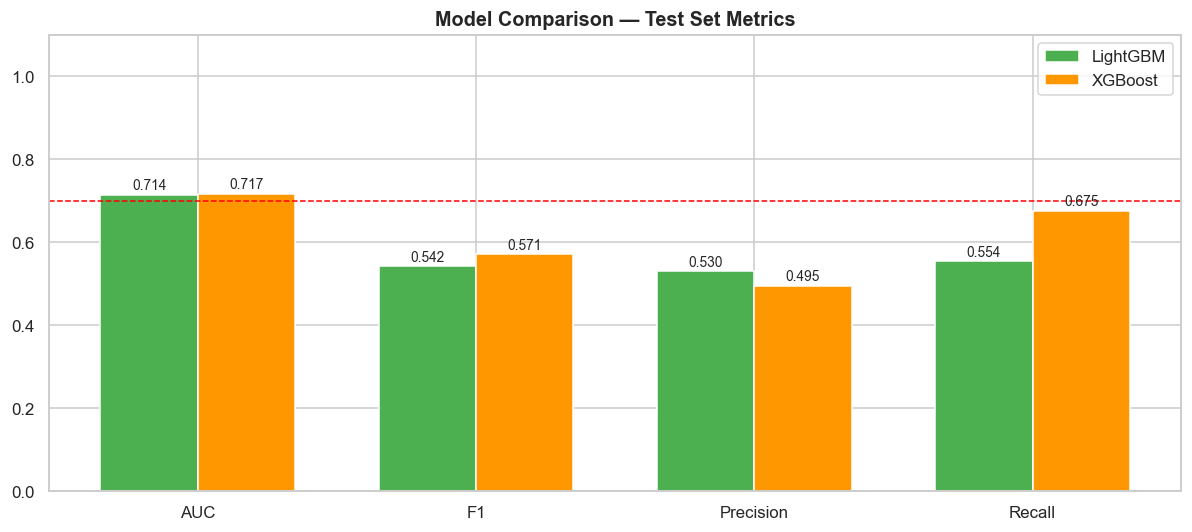

In [9]:
# Bar comparison
metrics = ['AUC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.35
colors = ['#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model, color=colors[i], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.7, color='red', linestyle='--', linewidth=1, label='AUC=0.70 target')
plt.tight_layout()
plt.show()

## SHAP Feature Importance (Best Model)

Best model: XGBoost


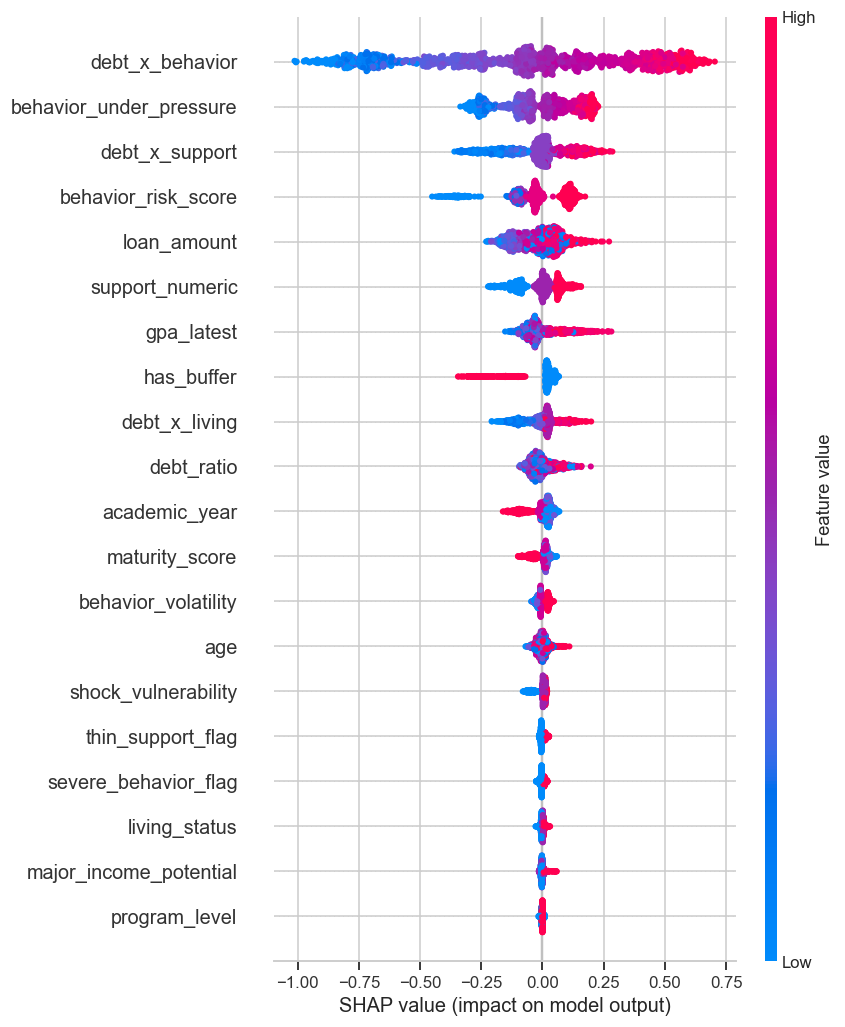

In [10]:
# Determine best model by AUC
best_name  = results_df['AUC'].idxmax()
best_model = {'LightGBM': lgb_model, 'XGBoost': xgb_model}[best_name]
print(f'Best model: {best_name}')

# SHAP — tree explainer works for both LightGBM and XGBoost
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # class 1 (default)

shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, max_display=20)

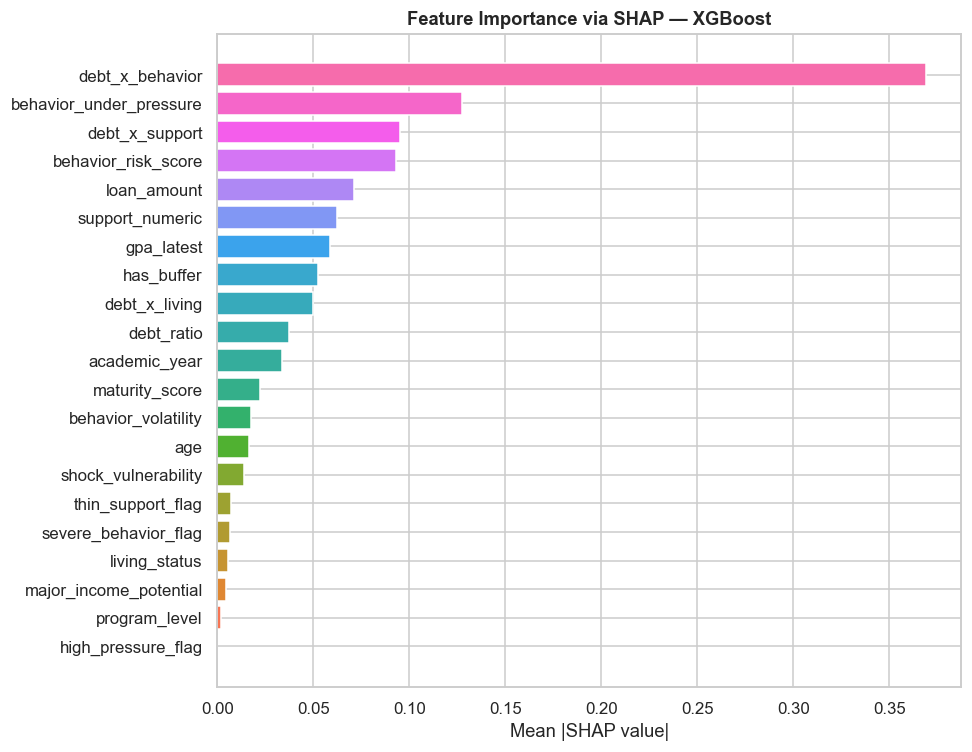

SHAP plot saved.


In [11]:
# Mean absolute SHAP — bar plot
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = sns.color_palette('husl', len(mean_shap))
ax.barh(mean_shap.index[::-1], mean_shap.values[::-1], color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Feature Importance via SHAP — {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()

fig.savefig(f'{OUTPUT_DIR}/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved.')

## Save Best Model

In [12]:
model_path = f'{OUTPUT_DIR}/best_model_{best_name.lower().replace(" ","_")}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

# Also save results summary
results_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv')

print(f'✅ Best model saved: {model_path}')
print(f'✅ Comparison table saved: {OUTPUT_DIR}/model_comparison.csv')

print('\n=== FINAL SUMMARY ===')
print(f'Dataset     : 10,001 students (Binary default prediction)')
print(f'Features    : {len(FEATURE_COLS)} features')
print(f'Best model  : {best_name}')
print(f'Test AUC    : {results_df.loc[best_name,"AUC"]:.4f}')
print(f'Test F1     : {results_df.loc[best_name,"F1"]:.4f}')

✅ Best model saved: ../../../output/alternative_model/best_model_xgboost.pkl
✅ Comparison table saved: ../../../output/alternative_model/model_comparison.csv

=== FINAL SUMMARY ===
Dataset     : 10,001 students (Binary default prediction)
Features    : 21 features
Best model  : XGBoost
Test AUC    : 0.7172
Test F1     : 0.5714
